In [1]:
import numpy as np
import mpmath as mp
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import Normalize
plt.style.use('custom_paper')

In [2]:
G = 1
M = 1

In [3]:
def compute_params(a, r0, e, z0, omega, theta0):
    dphi = theta0 - omega
    cosd = np.cos(dphi)
    sind = np.sin(dphi)
    k1 = (1 + e)**2 * (a**2 * (1 - e)**2 + r0**2 + z0**2 - 2 * a * (1 - e) * r0 * cosd)
    k2 = -4 * a * (1 - e) * (1 + e)**2 * r0 * sind
    k3 = 2 * (-1 + e**2) * (a**2 * (-1 + e**2) - r0**2 - z0**2 - 2 * a * e * r0 * cosd)
    k4 = -4 * a * (1 - e)**2 * (1 + e) * r0 * sind          # sign flipped
    k5 = (1 - e)**2 * (a**2 * (1 + e)**2 + r0**2 + z0**2 + 2 * a * (1 + e) * r0 * cosd)
    return dphi, k1, k2, k3, k4, k5    

def compute_roots(k1, k2, k3, k4, k5):
    coeffs = [k5, k4, k3, k2, k1]
    roots = np.roots(coeffs)
    q3 = next(r for r in roots if np.real(r) < 0 and np.imag(r) < 0)  # r1
    q2 = next(r for r in roots if np.real(r) < 0 and np.imag(r) > 0)  # r2
    q4 = next(r for r in roots if np.real(r) > 0 and np.imag(r) < 0)  # r3
    q1 = next(r for r in roots if np.real(r) > 0 and np.imag(r) > 0)  # r4
    return [q3, q2, q4, q1]

def compute_AB(roots):
    roots_sorted = sorted(roots, key=lambda z: (np.real(z), np.imag(z)))
    r1 = roots_sorted[0]
    r3 = roots_sorted[2]
    A1 = np.real(r1)
    B1 = np.abs(np.imag(r1))
    A2 = np.real(r3)
    B2 = np.abs(np.imag(r3))
    return [A1, B1, A2, B2]

def getallparams(params):
    a, r0, e, z0, omega, theta0 = params
    dphi, k1, k2, k3, k4, k5 = compute_params(*params)
    r1, r2, r3, r4 = compute_roots(k1, k2, k3, k4, k5)
    A1,B1,A2,B2 = compute_AB([r1,r2,r3,r4])
    output = [a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2]
    return output

In [4]:
def coeff(allparams):
    a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2 = allparams
    return -4 / (np.sqrt(k5) * np.abs(r1 - r3))

def split1(allparams):
    a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2 = allparams
    split1 = -(1 / (2 * (A1 - A2))) * (-A1**2 + A2**2 - B1**2 + B2**2 - np.sqrt(((A1 - A2)**2 + B1**2)**2 + 2 * (A1 - A2 - B1) * (A1 - A2 + B1) * B2**2 + B2**4))
    return split1

def split3(allparams):
    a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2 = allparams
    split = -(1 / (2 * (A1 - A2))) * (-A1**2 + A2**2 - B1**2 + B2**2 + np.sqrt(((A1 - A2)**2 + B1**2)**2 + 2 * (A1 - A2 - B1) * (A1 - A2 + B1) * B2**2 + B2**4))
    return split

def split2(allparams):
    a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2 = allparams
    numerator = -1 + A1**2 + B1**2 - np.sqrt((1 + A1**2)**2 + 2 * (-1 + A1**2) * B1**2 + B1**4)
    denominator = 2 * A1
    split2 = numerator / denominator
    return split2

In [5]:
def transformed_integral_wier_elliptic(params):
    allparams = getallparams(params)
    a,r0,e,z0,omega,theta0,dphi,k1,k2,k3,k4,k5,r1,r2,r3,r4,A1,B1,A2,B2 = allparams
    c = coeff(allparams)

    m  = ((r2 - r3) * (r1 - r4)) / ((r1 - r3) * (r2 - r4))
    n1 = ((-1j + r2) * (r1 - r4)) / ((-1j + r1) * (r2 - r4))
    n2 = ((1j  + r2) * (r1 - r4)) / ((1j  + r1) * (r2 - r4))

    jump_val_F = -2 * mp.ellipk(m).real
    kf = (1 + e * (2/(1 + r2**2) - 1))

    t3 = split3(allparams)
    t2 = split2(allparams)
    s2_t3 = ((r2 - r4) * (-(r1 - t3))) / ((r1 - r4) * (-(r2 - t3)))
    s2_t2 = ((r2 - r4) * (-(r1 - t2))) / ((r1 - r4) * (-(r2 - t2)))

    s  = np.sqrt(s2_t3)
    x  = 1 - s2_t3
    y  = 1 - m*s2_t3
    p  = 1 - n1*s2_t3
    beta  = x - y
    gamma = 1 - y
    alpha = p - y
    
    RJ_sum = 2 * mp.elliprj(beta, 0, gamma, alpha)
    S_full = -(n1 * (s**3) / 3.0) * RJ_sum
    RF = mp.elliprf(1 - s2_t3, 1 - m*s2_t3, 1)
    jump1_pi1 = S_full - 2*s*RF.real
    
    p2 = 1 - n2*s2_t3
    alpha2 = p2 - y          # same y as above (depends only on s2_t3, m)
    RJ_sum2 = 2 * mp.elliprj(beta, 0, gamma, alpha2)
    S_full2 = -(n2 * (s**3) / 3.0) * RJ_sum2
    jump1_pi2 = S_full2 - 2*s*RF.real


    s_p = np.sqrt(s2_t2)
    x_p = 1 - s2_t2
    y_p = 1 - m*s2_t2
    p_p = 1 - n2*s2_t2
    a_p = -p_p
    Delta = 3*np.pi*1j / np.sqrt((a_p + x_p) * (a_p + y_p) * (a_p + 1))
    jump2_pi2 = (n2 * s_p**3 * Delta) / 3.0

    k1 = (((1j * e) * (r1 - r2)) / ((-1j + r1) * (-1j + r2)))
    k2 = -(((1j * e) * (r1 - r2)) / ((1j + r1) * (1j + r2)))

    difference = c * (kf*jump_val_F + k1*jump1_pi1 + k2*jump1_pi2 - k2*jump2_pi2)
    return difference


In [6]:
def phi_ana_elliptic(x0, y0, z0, a, dtheta, Theta0, e, omega):
    r0 = np.sqrt(x0**2 + y0**2)
    theta0 = np.arctan2(y0, x0)

    params = (a, r0, e, z0, omega, theta0)
    integral = transformed_integral_wier_elliptic(params)

    prefactor = (-G * M) / (2.0 * dtheta)
    return prefactor * integral

In [7]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from scipy.special import roots_legendre

N_QUAD = 4096 * 4
nodes_np, weights_np = roots_legendre(N_QUAD)

thetas_base_np = nodes_np
wts_base_np = weights_np

thetas_base_jax = jnp.asarray(thetas_base_np)
wts_base_jax = jnp.asarray(wts_base_np)

N_E_QUAD = 128  # You can increase for higher accuracy
e_nodes_np, e_weights_np = roots_legendre(N_E_QUAD)

e_nodes_jax = jnp.asarray(e_nodes_np)
e_weights_jax = jnp.asarray(e_weights_np)


@jax.jit
def ellipticE_jax(phi, m):
    t_nodes = 0.5 * phi * (e_nodes_jax + 1.0)
    t_weights = 0.5 * phi * e_weights_jax

    integrand = jnp.sqrt(1.0 - m * jnp.sin(t_nodes) ** 2)

    integral = jnp.sum(t_weights * integrand)
    return integral

@jax.jit
def phi_num_ad_scalar(x0, y0, z0, a, e, omega, dtheta, Theta0):
    r0 = jnp.sqrt(x0**2 + y0**2)
    theta0 = jnp.arctan2(y0, x0)

    thetas_jax = Theta0 + dtheta * thetas_base_jax
    wts_jax = wts_base_jax * dtheta

    R_theta = a * (1.0 - e**2) / (1.0 + e * jnp.cos(thetas_jax - omega))

    d = jnp.sqrt(R_theta**2 + r0**2 + z0**2 - 2.0 * R_theta * r0 * jnp.cos(thetas_jax - theta0))

    integral = jnp.sum(wts_jax / d)

    prefactor = (-G * M) / (2.0 * dtheta)

    return prefactor * integral
grad_phi_cart = jax.grad(phi_num_ad_scalar, argnums=(0, 1, 2))

@jax.jit
def accel_cyl_scalar(x0, y0, z0, a, e, omega, dtheta, Theta0):
    gx, gy, gz = grad_phi_cart(x0, y0, z0, a, e, omega, dtheta, Theta0)

    ax = -gx
    ay = -gy
    az = -gz

    r = jnp.sqrt(x0**2 + y0**2)
    r_safe = jnp.where(r > 1e-12, r, 1e-12)  # Avoid division by zero

    ar = (x0 * ax + y0 * ay) / r_safe
    atheta = (x0 * ay - y0 * ax) / r_safe

    return ar, atheta, az

In [8]:
x_vals = np.linspace(-2, 2, 100)
y_vals = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_vals, y_vals)
a,dtheta,Theta0,z0, e, omega = 1.0, np.pi, 0.0, 0.1, 0.5, 2.0


In [9]:
phi_num_vals = np.zeros_like(X)
phi_ana_vals = np.zeros_like(X)

ar_num = np.zeros_like(X)
atheta_num = np.zeros_like(X)
az_num = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x = X[i, j]
        y = Y[i, j]

        phi_num_vals[i, j] = float(phi_num_ad_scalar(x, y, z0, a, e, omega, dtheta, Theta0))
        a_r, a_theta, a_z = accel_cyl_scalar(x, y, z0, a, e, omega, dtheta, Theta0)
        ar_num[i, j] = float(a_r)
        atheta_num[i, j] = float(a_theta)
        az_num[i, j] = float(a_z)

        phi_ana_vals[i, j] = float(phi_ana_elliptic(x, y, z0, a, dtheta, Theta0, e, omega).real)

/tmp/ipykernel_19457/3950821470.py:13: RuntimeWarning: divide by zero encountered in log10
  diff = np.log10(np.abs(phi_num_vals - phi_ana_vals))


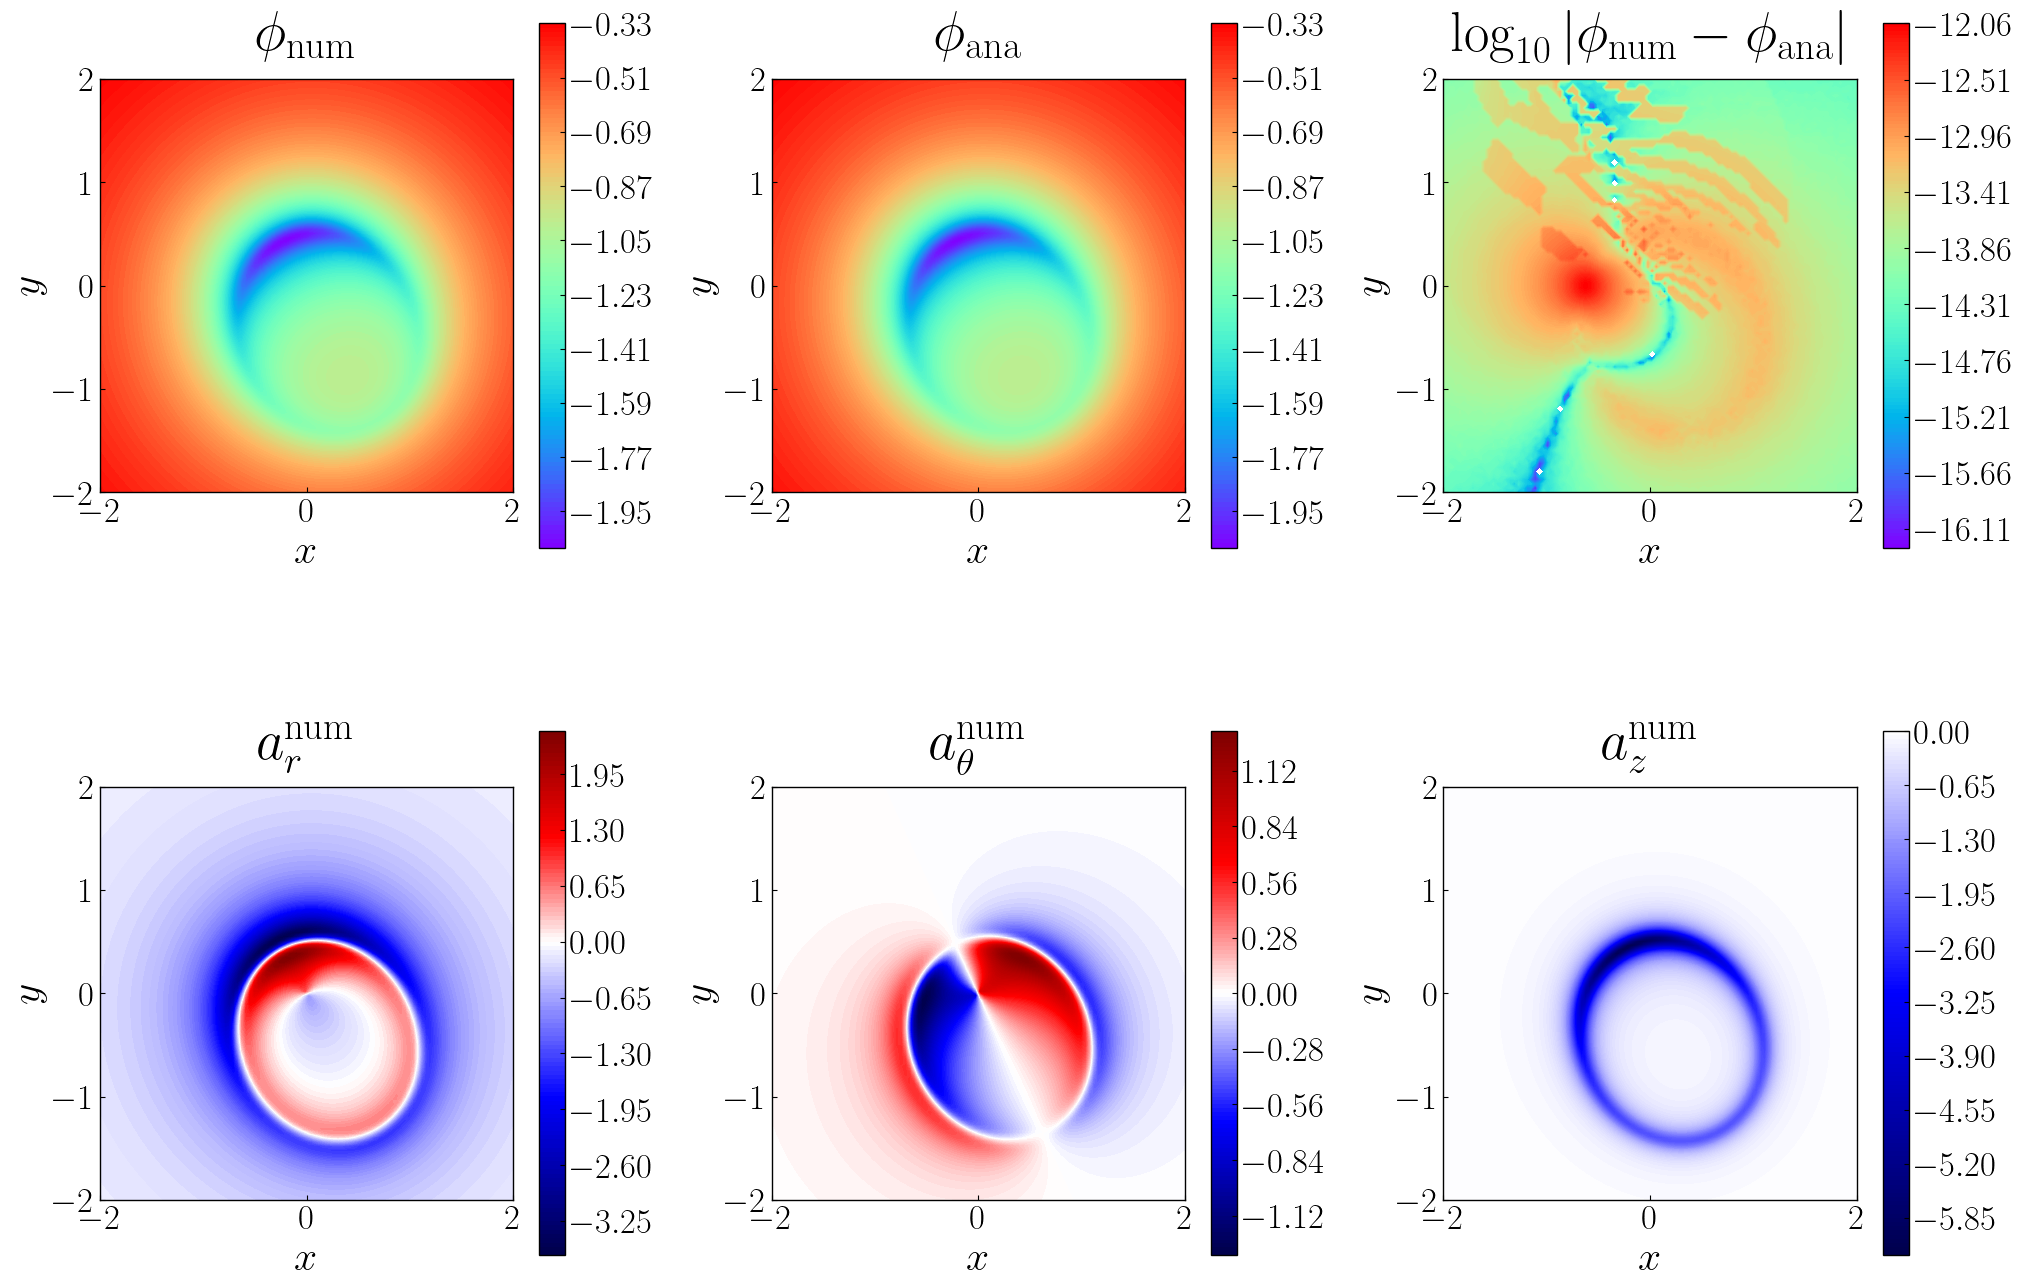

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.subplots_adjust(wspace=0.3, hspace=0.35)

axes[0, 0].set_title(r"$\phi_{\mathrm{num}}$")
im0 = axes[0, 0].contourf(X, Y, phi_num_vals, 150, cmap='rainbow')
fig.colorbar(im0, ax=axes[0, 0])

axes[0, 1].set_title(r"$\phi_{\mathrm{ana}}$")
im1 = axes[0, 1].contourf(X, Y, phi_ana_vals, 150, cmap='rainbow')
fig.colorbar(im1, ax=axes[0, 1])

axes[0, 2].set_title(r"$\log_{10}|\phi_{\mathrm{num}} - \phi_{\mathrm{ana}}|$")
diff = np.log10(np.abs(phi_num_vals - phi_ana_vals))
im2 = axes[0, 2].contourf(X, Y, diff, 150, cmap='rainbow')
fig.colorbar(im2, ax=axes[0, 2])

axes[1, 0].set_title(r"$a_r^{\mathrm{num}}$")
norm_ar_num = TwoSlopeNorm(vmin=np.min(ar_num), vcenter=0, vmax=np.max(ar_num))
im3 = axes[1, 0].contourf(X, Y, ar_num, 150, cmap='seismic', norm=norm_ar_num)
fig.colorbar(im3, ax=axes[1, 0])

axes[1, 1].set_title(r"$a_\theta^{\mathrm{num}}$")
norm_atheta_num = TwoSlopeNorm(vmin=np.min(atheta_num), vcenter=0, vmax=np.max(atheta_num))
im6 = axes[1, 1].contourf(X, Y, atheta_num, 150, cmap='seismic', norm=norm_atheta_num)
fig.colorbar(im6, ax=axes[1, 1])

axes[1, 2].set_title(r"$a_z^{\mathrm{num}}$")
norm_az_num = TwoSlopeNorm(vmin=np.min(az_num), vcenter=0, vmax=1e-3)
im9 = axes[1, 2].contourf(X, Y, az_num, 150, cmap='seismic', norm=norm_az_num)
fig.colorbar(im9, ax=axes[1, 2])

for ax in axes.flat:
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_aspect('equal')   

plt.savefig("uniform_eccentric_ring_plot.png", dpi=300, bbox_inches="tight")
plt.show()